# Interpretation

Этот ноутбук предназначен для глубокого анализа и интерпретации обученных моделей. Используется метод SHAP (SHapley Additive exPlanations) для понимания того, как признаки влияют на прогноз.

In [1]:
import sys
import json
import joblib

import pandas as pd
import numpy as np

from pathlib import Path
import logging
from IPython.display import Image, display

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from src.evaluation.explainer import ModelExplainer

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [ ]:
model_name = "logreg"  # logreg # xgb, lgbm, catboost

DATA_DIR = ROOT / "data"
PROCESSED_DATA = DATA_DIR / "processed"

TRAIN_DATA = PROCESSED_DATA / "train_features.parquet"
FEATURES_JSON = PROCESSED_DATA / "selected_features.json"

ARTIFACT_DIR = ROOT / "artifacts"
MODEL_DIR = ARTIFACT_DIR / f"{model_name}_model"

MODEL_PATH = MODEL_DIR / "model.joblib"
XAI_DIR = MODEL_DIR / "xai"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
XAI_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(TRAIN_DATA)

with open(FEATURES_JSON, "r") as f:
    selected_features = json.load(f)

X = df[selected_features].astype(np.float64)
y = df["TARGET"]

print(f"Dataset shape: {X.shape}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

model_wrapper = joblib.load(MODEL_PATH)
final_model = model_wrapper

print(f"Loaded model: {model_name}")
print(f"Model type: {type(final_model).__name__}")

Dataset shape: (307511, 250)
Loaded model: logreg
Model type: LogRegModel


Создадим SHAP Sample

In [3]:
X_sample = final_model.transform(X.sample(min(1000, len(X)), random_state=42))
X_sample = final_model.transform(X_sample)
print(f"SHAP sample shape: {X_sample.shape}")

SHAP sample shape: (1000, 250)


## Глобальная интерпретация (Global SHAP)
Помогает понять общие закономерности: какие признаки наиболее важны для модели и как их значения коррелируют с вероятностью дефолта.

#### **Beeswarm plot:**

Показывает, какие признаки наиболее влияют на вероятность дефолта. Цвет (красный/синий) означает значение признака, а положение на оси X — вклад в предсказание.

#### **Bar plot:**

Показывает глобальную важность признаков, основанную на средних абсолютных значениях SHAP.

In [4]:
explainer = ModelExplainer(model=final_model, X_train=X_sample, feature_names=selected_features, output_dir=XAI_DIR)
logger.info("Explainer initialized successfully!")

explainer.compute_global_shap(X_sample=X_sample)

2026-05-08 15:39:21,250 | INFO | Initializing explainer for LogRegModel
2026-05-08 15:39:21,251 | INFO | Raw model type: <class 'src.models.logreg_model.LogRegModel'>
2026-05-08 15:39:21,253 | INFO | Unwrapped wrapper -> Pipeline
2026-05-08 15:39:21,259 | INFO | Detected Pipeline - using model.predict_proba directly
2026-05-08 15:39:21,267 | INFO | Explainer initialized successfully!
2026-05-08 15:39:21,268 | INFO | Computing SHAP values...
PermutationExplainer explainer: 1001it [04:26,  3.67it/s]                          
2026-05-08 15:43:47,415 | INFO | Raw SHAP values shape: (1000, 250, 2)
2026-05-08 15:43:47,415 | INFO | Selecting class 1 from SHAP values.
2026-05-08 15:43:47,420 | INFO | Final SHAP values shape for plotting: (1000, 250)


.values =
array([[-6.18886481e-05,  6.15154167e-04, -3.64636721e-04, ...,
         1.19345289e-07, -6.30611815e-07,  3.12145865e-11],
       [-1.40845130e-04, -9.58492706e-04, -3.87451719e-04, ...,
         8.48845711e-07, -2.21975091e-07,  1.77695636e-11],
       [-4.51704037e-05, -3.01043117e-04, -3.42626279e-04, ...,
         1.30202301e-07, -1.45754622e-07,  6.94772018e-12],
       ...,
       [-1.49663336e-04, -1.18132189e-03,  1.43132172e-04, ...,
         3.69609904e-06, -8.19271286e-07,  2.33630615e-10],
       [-2.92745162e-04,  1.37655901e-03, -7.16681844e-04, ...,
         1.07588753e-06, -9.49451488e-07,  5.52822788e-11],
       [-2.03727785e-04, -5.73464711e-04,  4.38219260e-04, ...,
         6.90950968e-07, -3.81561385e-07,  1.76417214e-11]],
      shape=(1000, 250))

.base_values =
array([0.99541761, 0.99541761, 0.99541761, 0.99541761, 0.99541761,
       0.99541761, 0.99541761, 0.99541761, 0.99541761, 0.99541761,
       0.99541761, 0.99541761, 0.99541761, 0.99541761, 0.9

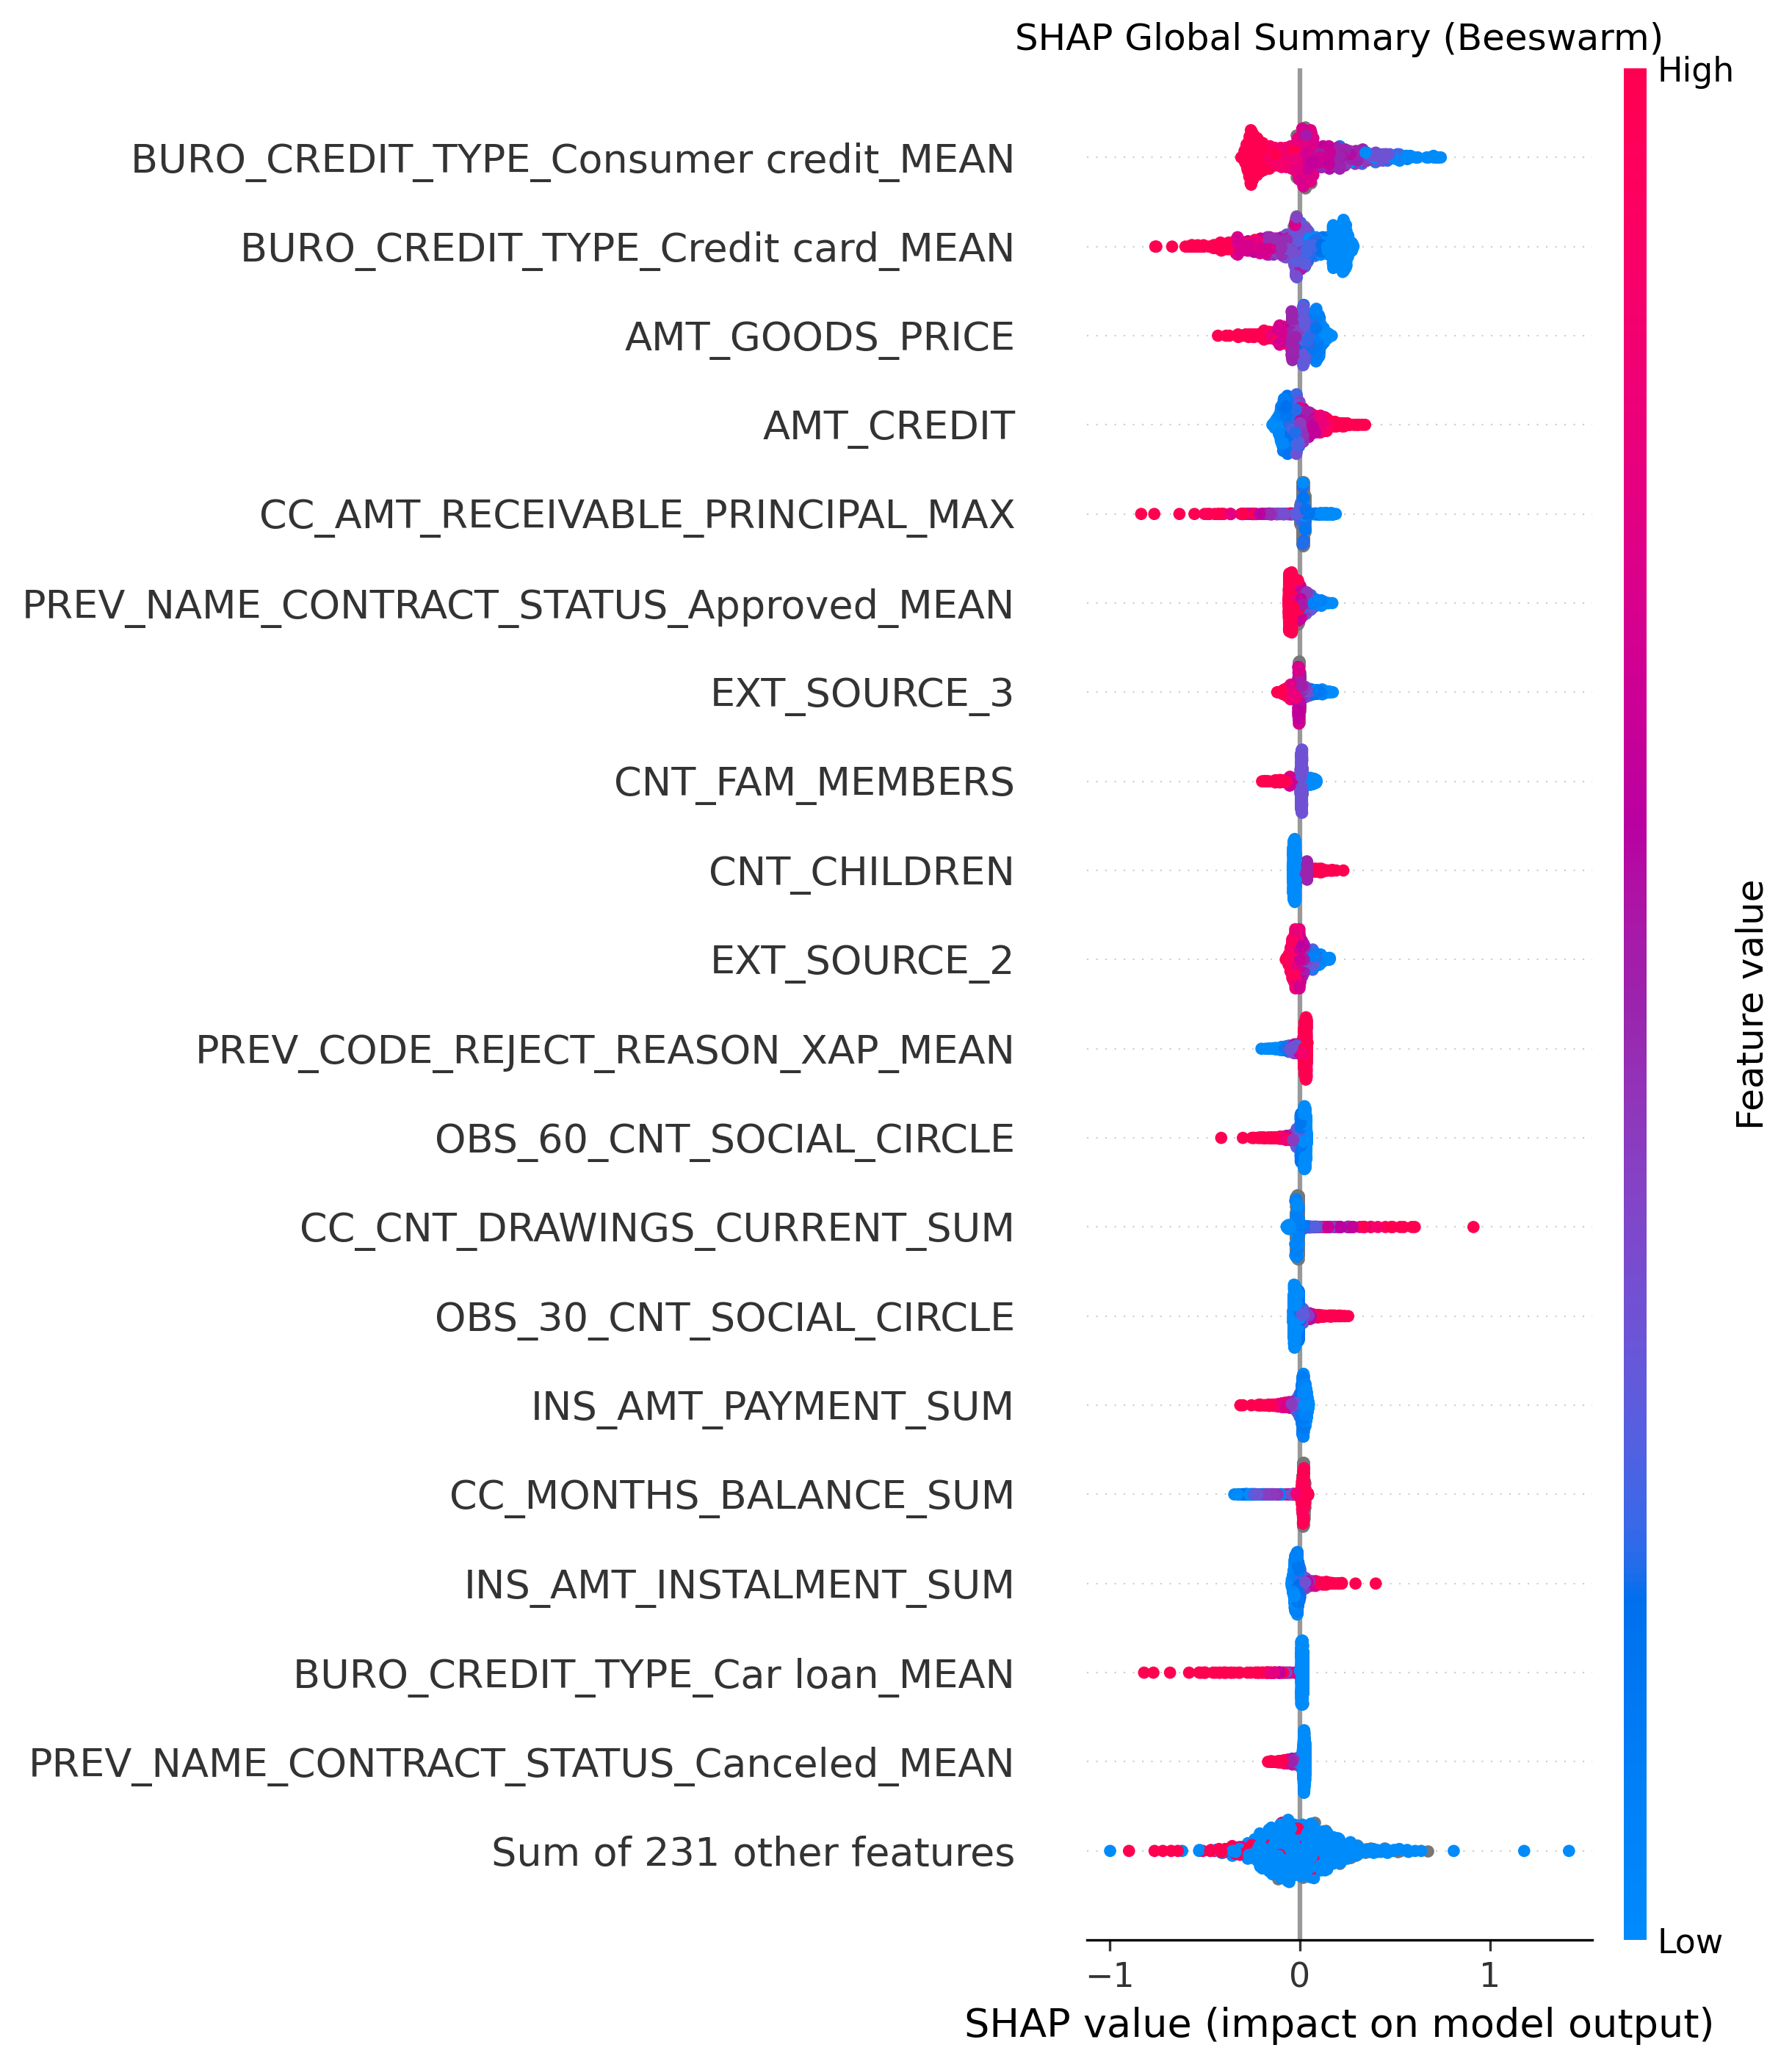

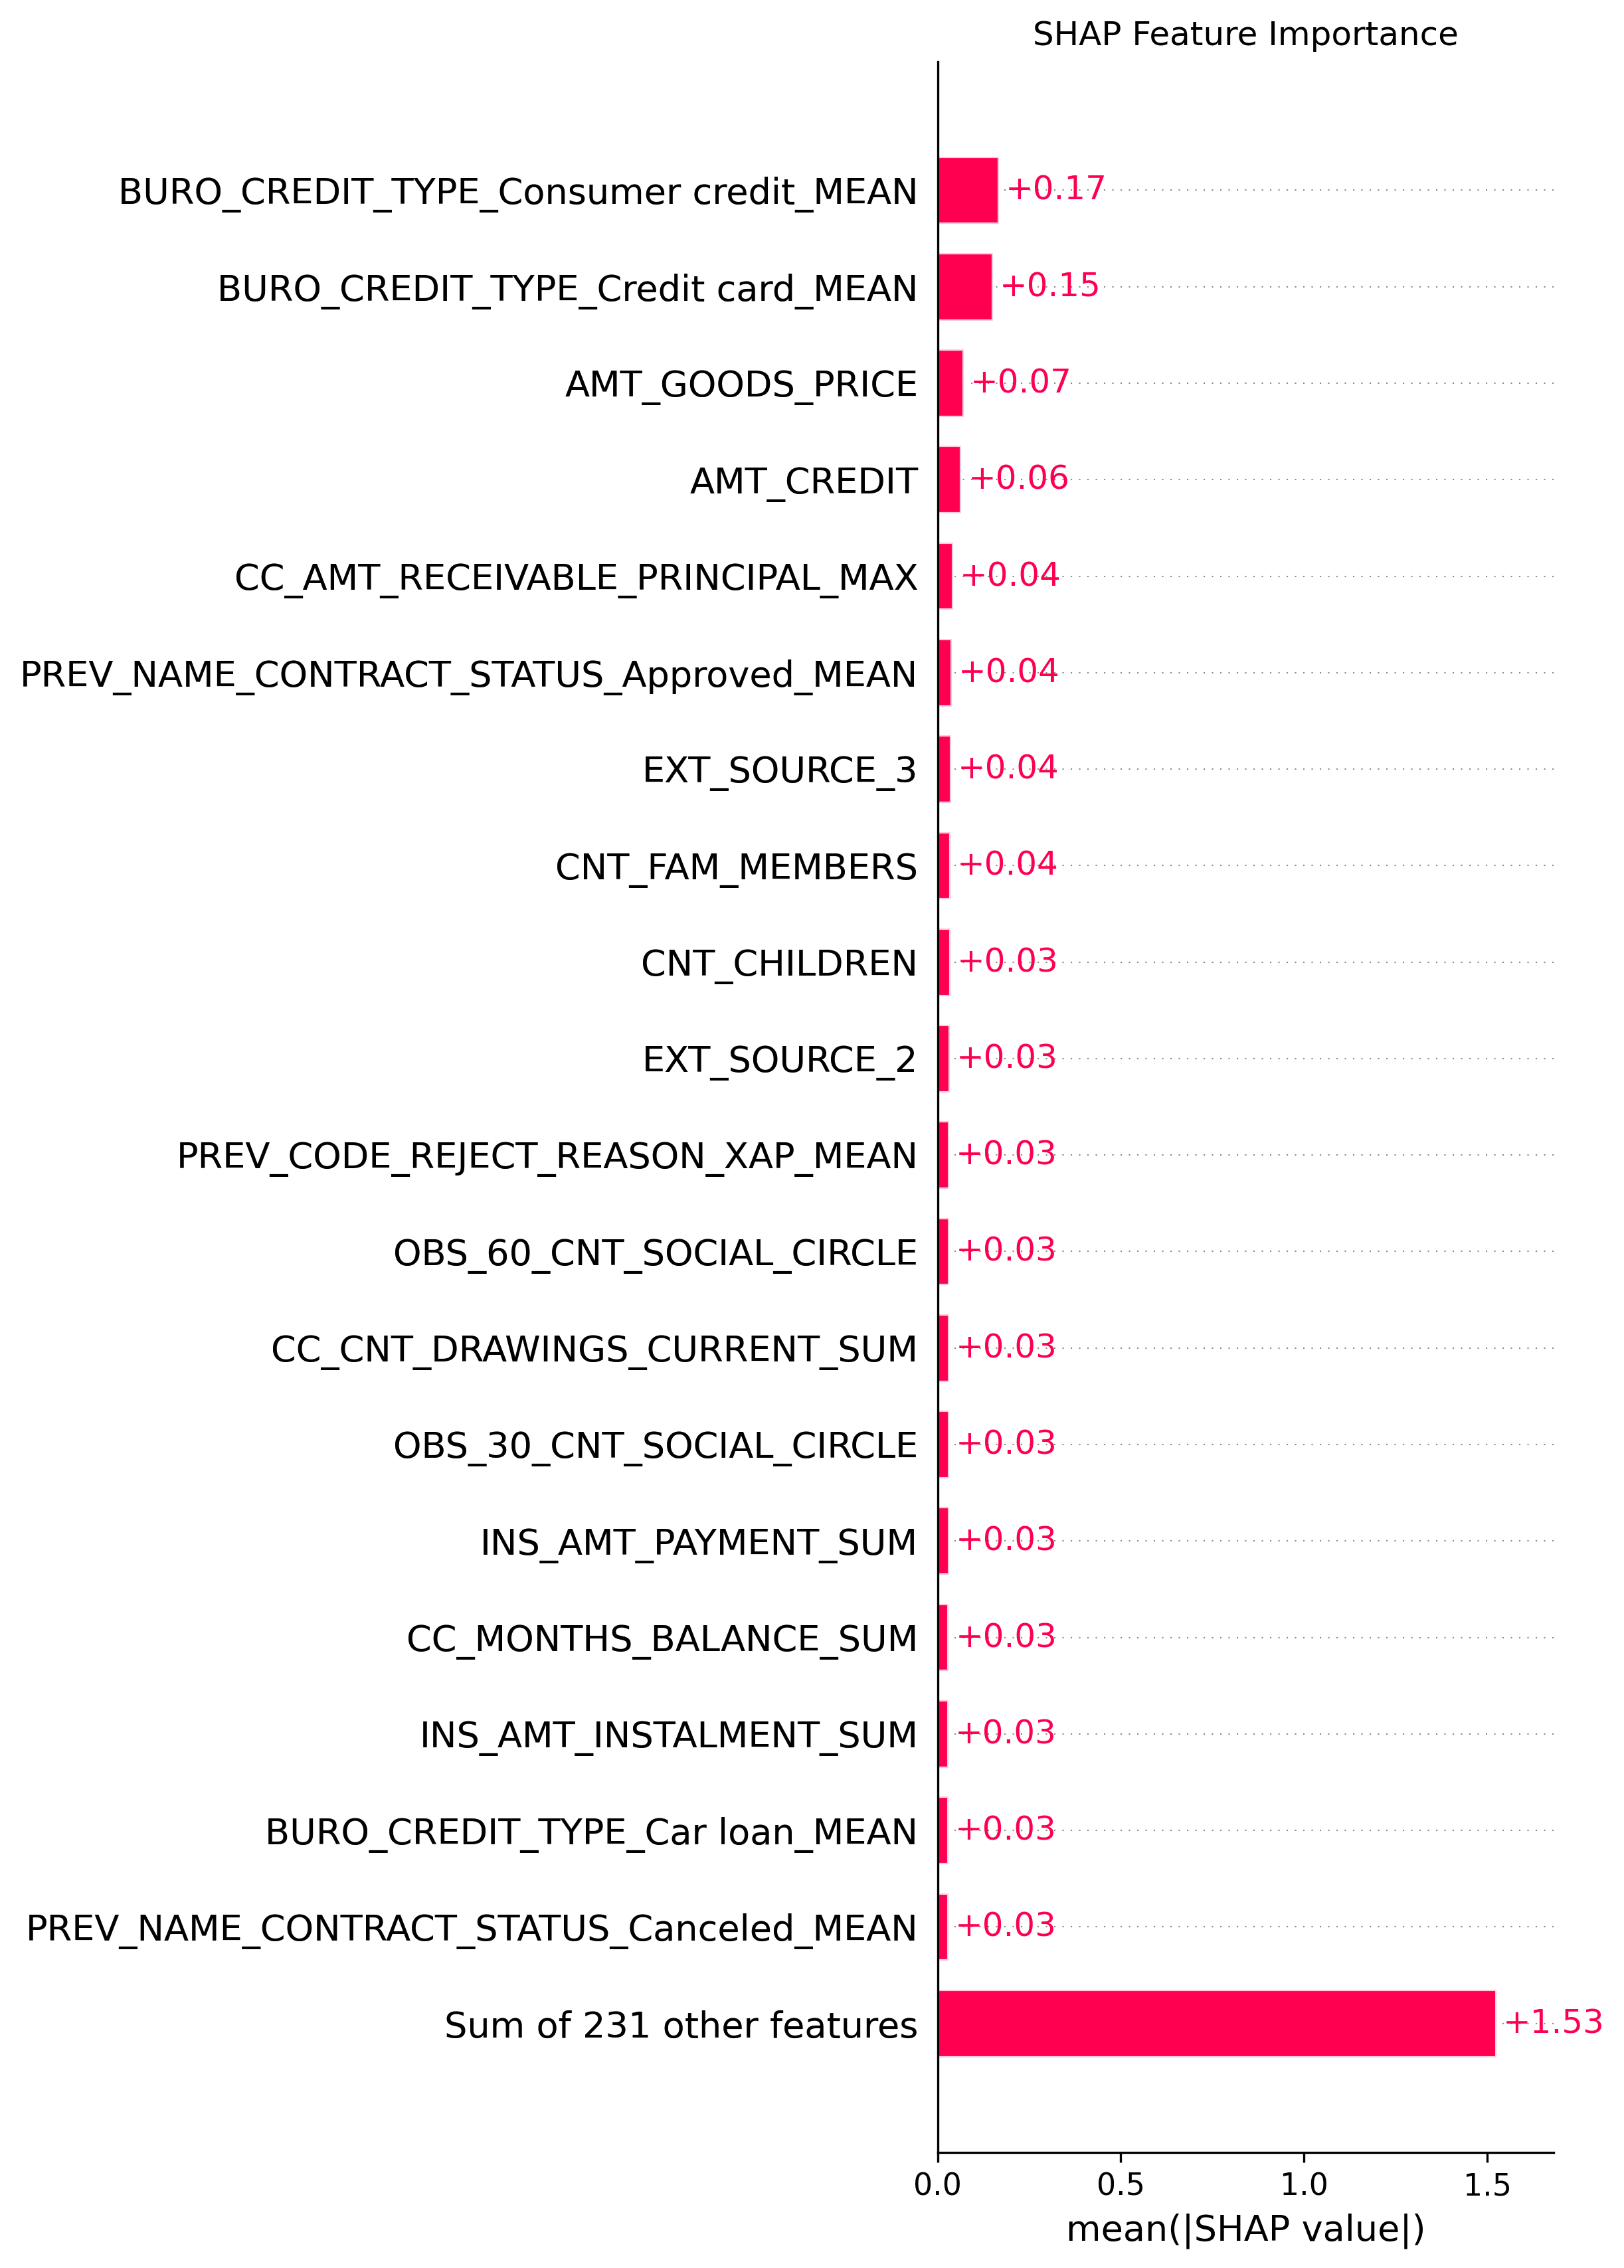

In [5]:
display(Image(filename= XAI_DIR / "shap_summary_beeswarm.png"))
display(Image(filename= XAI_DIR / "shap_summary_bar.png"))

## Feature Importance

In [6]:
importance_df = (explainer.get_feature_importance())

top_features = (explainer.get_feature_importance().head(3)["feature"].tolist())
print(f"Top features: {top_features}")

importance_df.head(20)

Top features: ['BURO_CREDIT_TYPE_Mortgage_MEAN', 'CC_AMT_RECEIVABLE_PRINCIPAL_MAX', 'CC_AMT_RECEIVABLE_PRINCIPAL_VAR']


,feature,importance
0,BURO_CREDIT_TYPE_Mortgage_MEAN,0.008697
1,CC_AMT_RECEIVABLE_PRINCIPAL_MAX,0.007602
2,CC_AMT_RECEIVABLE_PRINCIPAL_VAR,0.005690
3,AMT_CREDIT,0.004017
4,CC_CNT_DRAWINGS_CURRENT_SUM,0.003972
5,AMT_GOODS_PRICE,0.003958
6,CC_CNT_DRAWINGS_POS_CURRENT_SUM,0.003555
7,CC_AMT_TOTAL_RECEIVABLE_VAR,0.003302
8,CC_AMT_TOTAL_RECEIVABLE_MAX,0.003208
9,CC_AMT_RECIVABLE_VAR,0.003207


## Локальная интерпретация (Local SHAP)

#### **Waterfall plots**
Объясняют, почему модель приняла решение для конкретного клиента.

In [ ]:
probs = final_model.predict_proba(X_sample)

2026-05-08 15:43:47,735 | INFO | Generating local SHAP explanation...


HIGH RISK CLIENT (Prob: 1.0000)


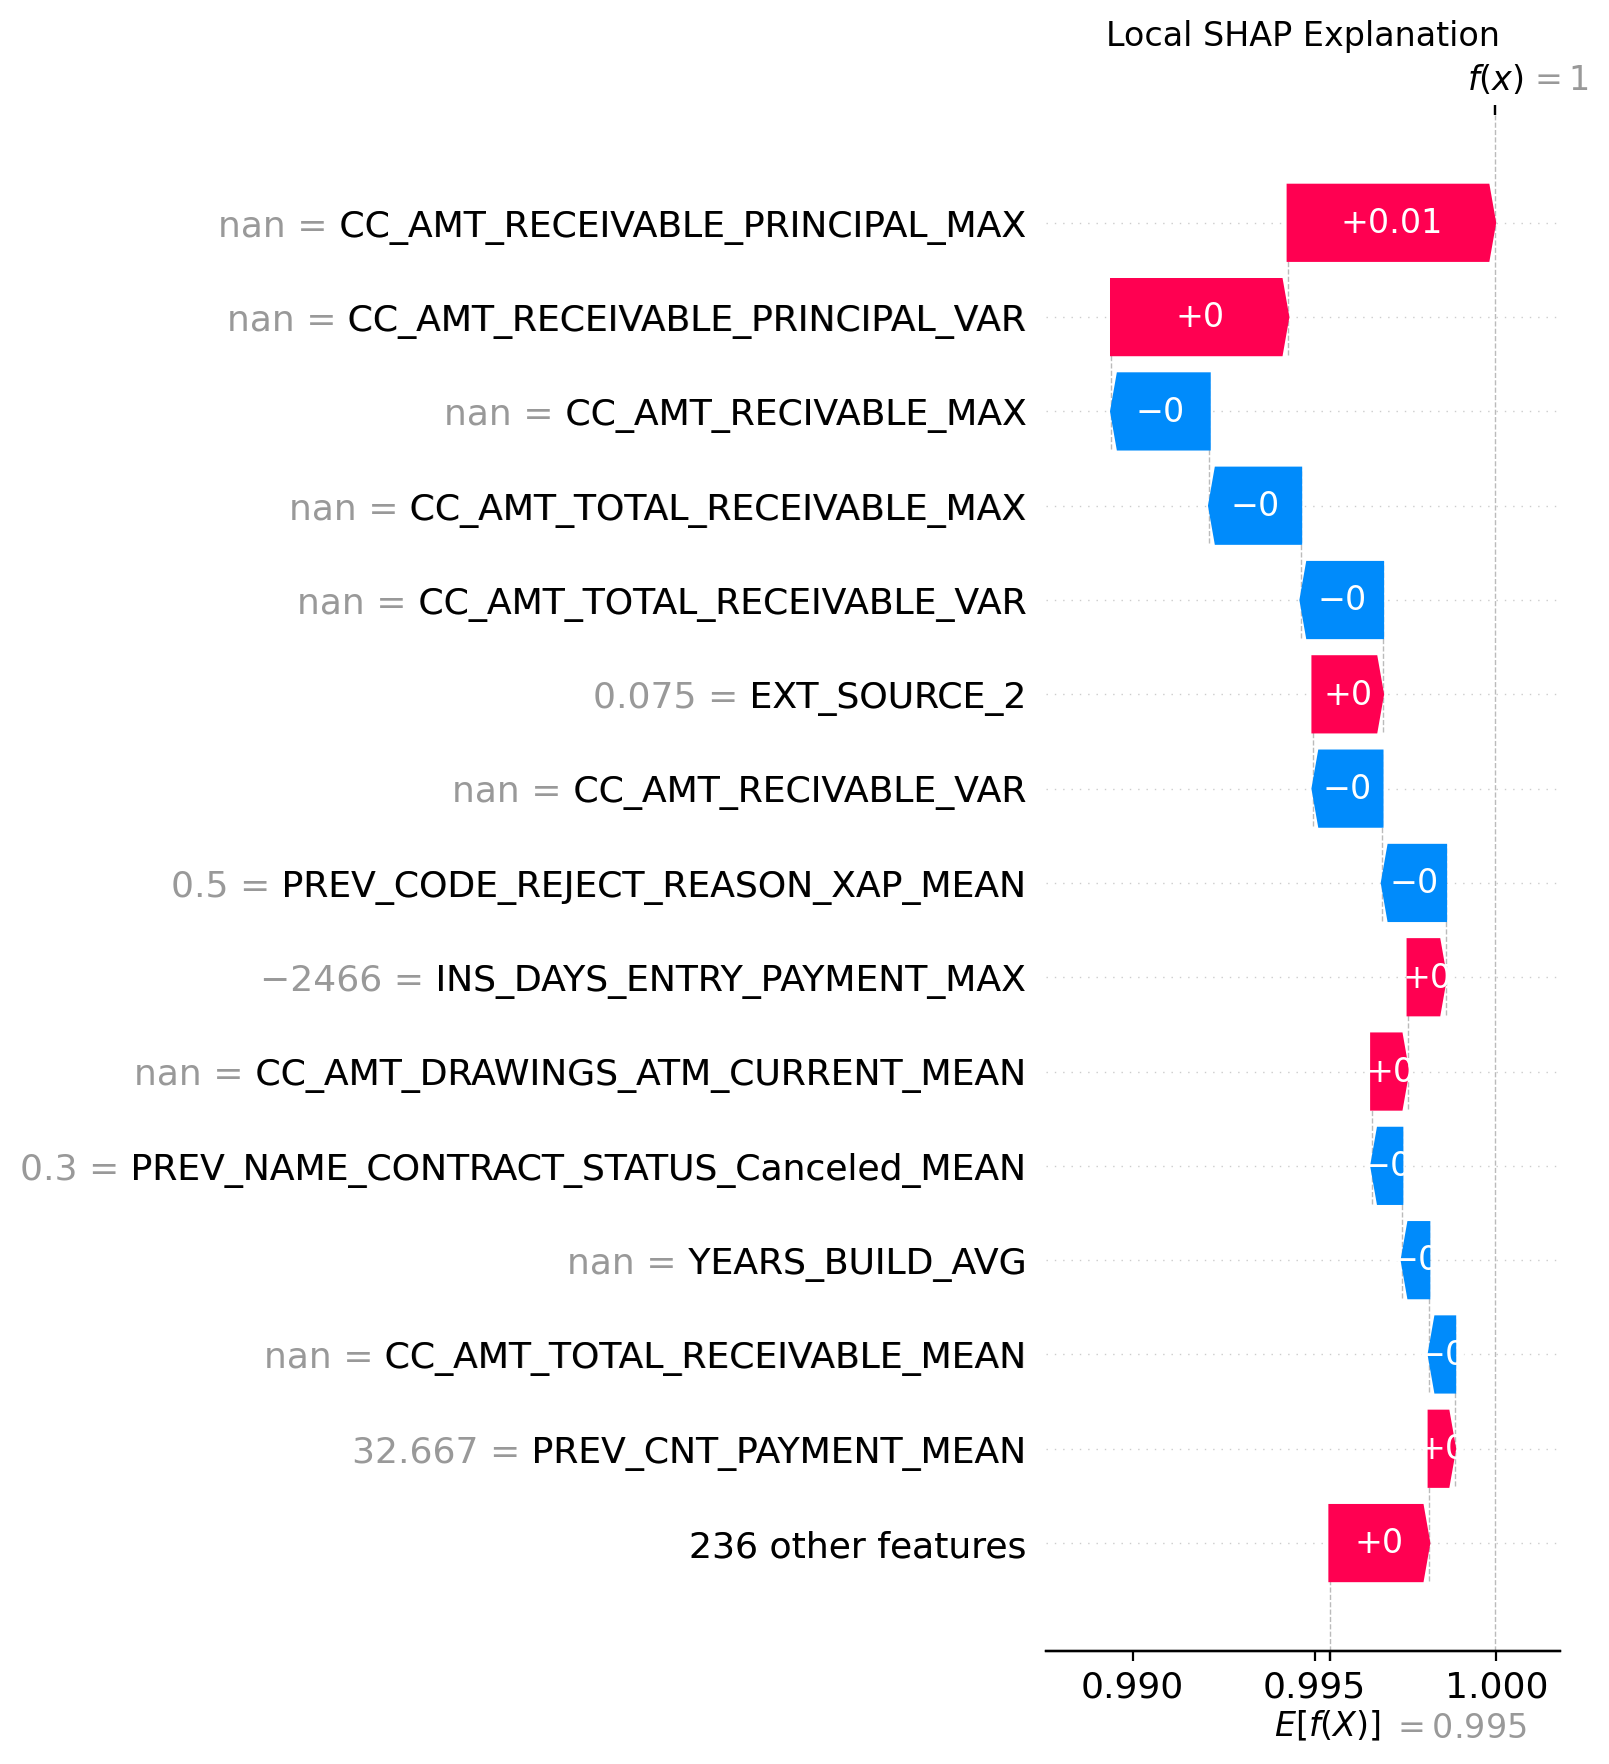

2026-05-08 15:43:49,727 | INFO | Generating local SHAP explanation...


LOW RISK CLIENT (Prob: 0.0801)


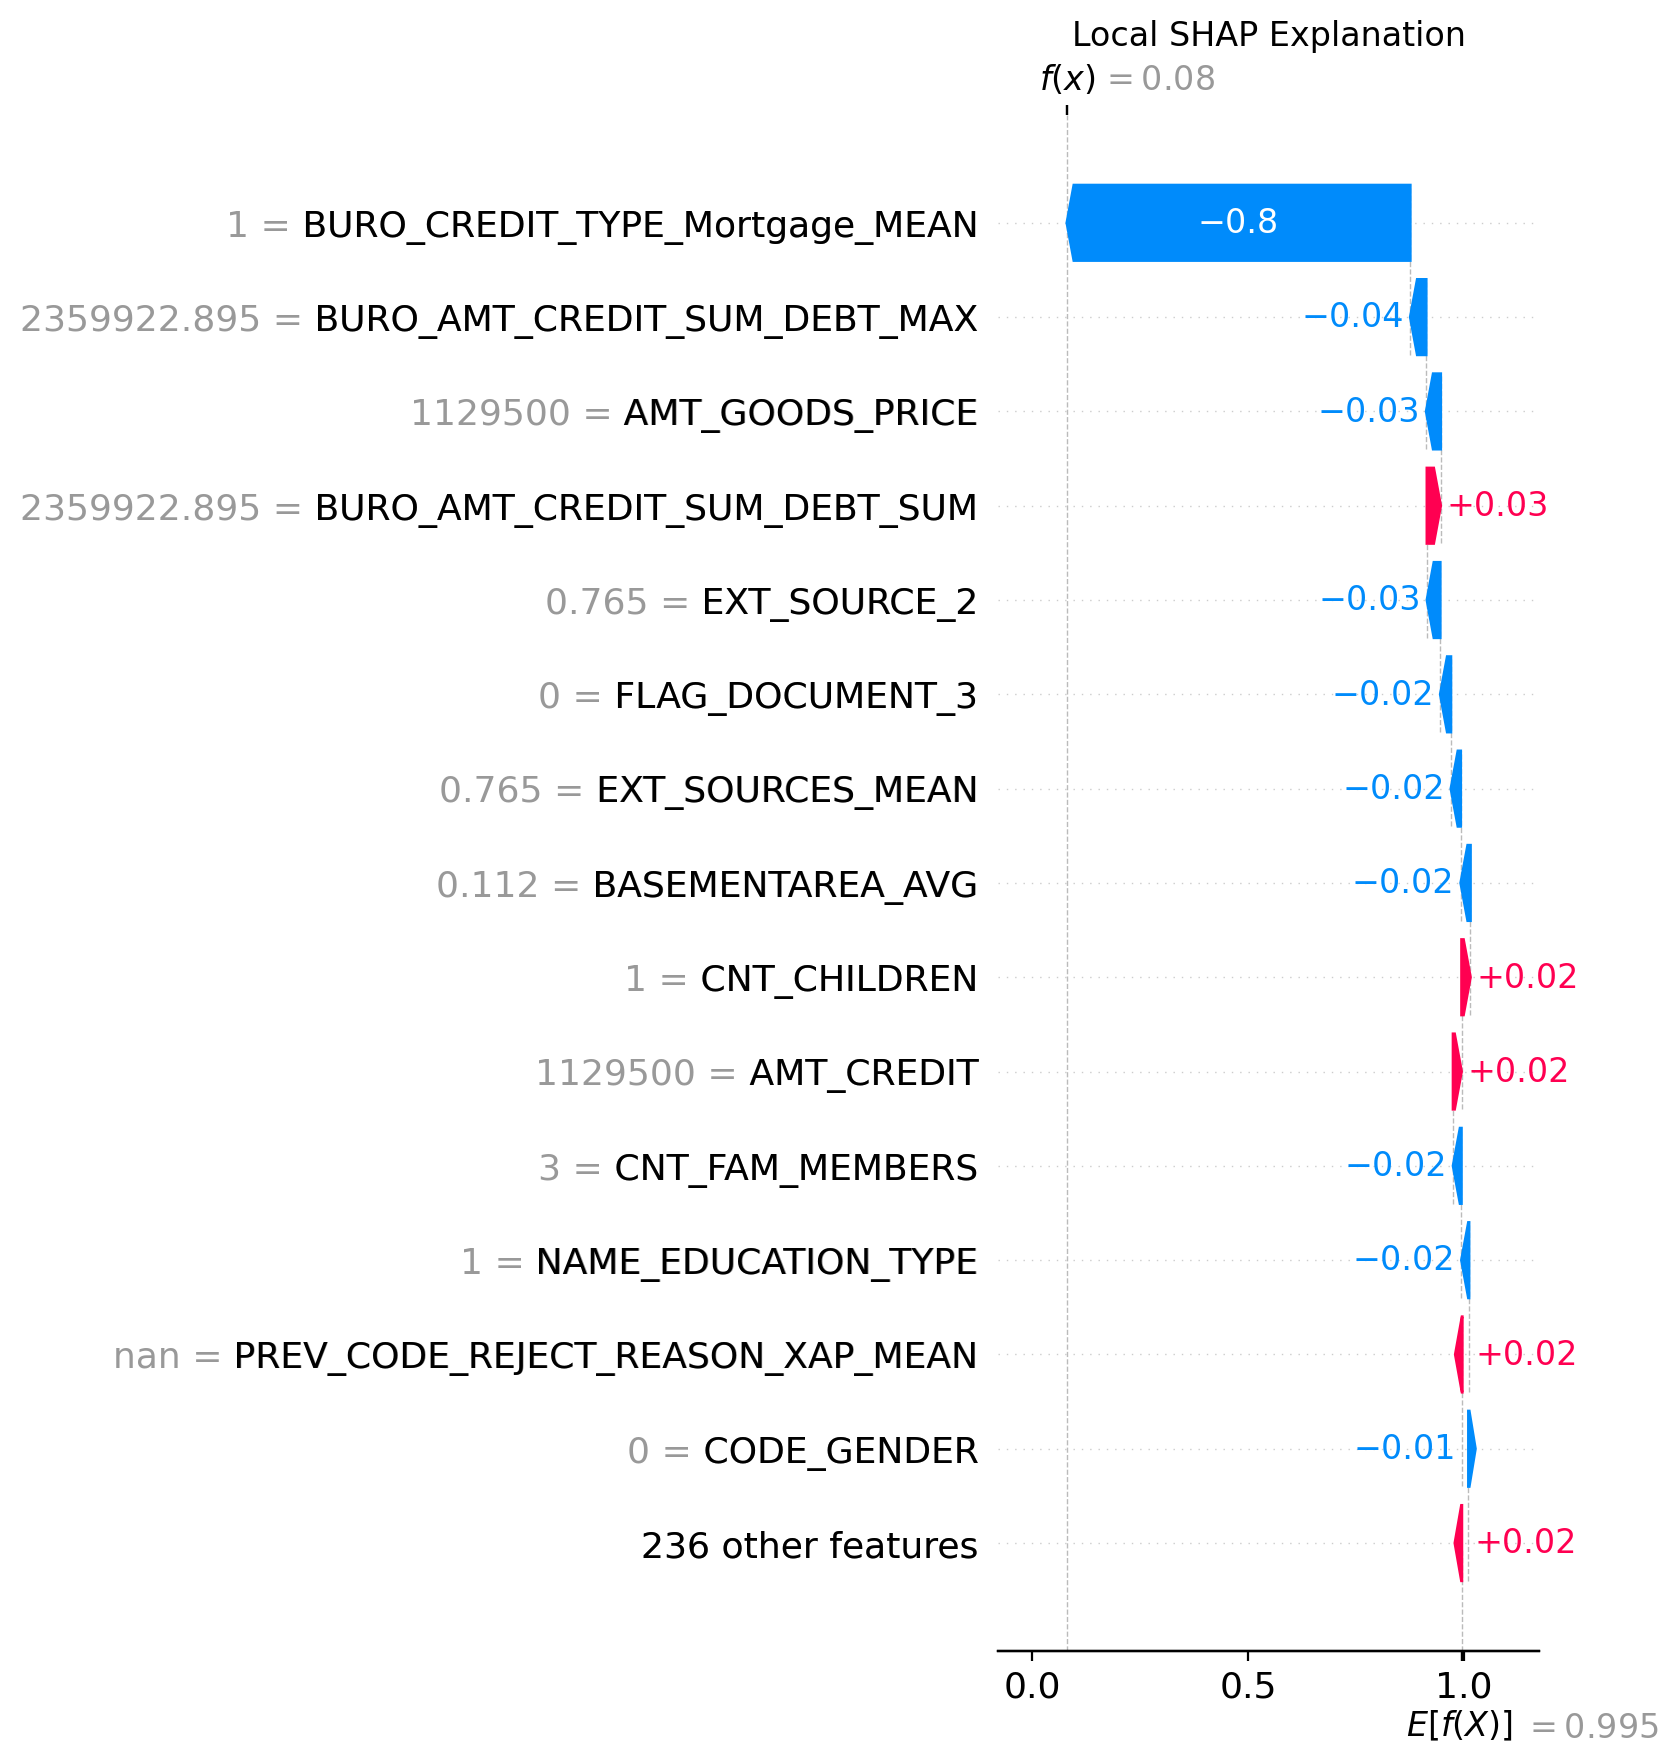

In [ ]:
# Клиент с высоким риском дефолта
high_risk_idx = np.argmax(probs)

print(f"HIGH RISK CLIENT (Prob: {probs[high_risk_idx]:.4f})")

instance_high = X_sample.iloc[high_risk_idx]

path_high = explainer.explain_local_shap(instance=instance_high, save_path= str (XAI_DIR / "local_shap_waterfall_high.png"))

display(Image(filename=path_high))

# Клиент с низким риском дефолта
low_risk_idx = np.argmin(probs)

print(f"LOW RISK CLIENT (Prob: {probs[low_risk_idx]:.4f})")

instance_low = X_sample.iloc[low_risk_idx]

path_low = explainer.explain_local_shap(instance=instance_low, save_path= str(XAI_DIR / f"local_shap_waterfall_low.png"))

display(Image(filename=path_low))


## Ключевые выводы
Интерпретация подтверждает, что модель принимает решения на основе логически значимых факторов риска.